In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix




Load Data

In [2]:
df = pd.read_csv("Placement_Prediction_data.csv")

In [3]:
df.head()

,Unnamed: 0,StudentId,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus
0,0,1,7.5,1,1,1,6,4.4,No,No,61,79,2,NotPlaced
1,1,2,8.9,0,3,2,9,4.0,Yes,Yes,78,82,0,Placed
2,2,3,7.3,1,2,2,8,4.8,Yes,No,79,80,2,NotPlaced
3,3,4,7.5,1,1,2,8,4.4,Yes,Yes,81,80,0,Placed
4,4,5,8.3,1,2,2,8,4.5,Yes,Yes,74,88,0,Placed


In [4]:
df.shape

(10000, 14)

In [5]:
df.isnull().sum()

Unnamed: 0                    0
StudentId                     0
CGPA                          0
Major Projects                0
Workshops/Certificatios       0
Mini Projects                 0
Skills                        0
Communication Skill Rating    0
Internship                    0
Hackathon                     0
12th Percentage               0
10th Percentage               0
backlogs                      0
PlacementStatus               0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  10000 non-null  int64  
 1   StudentId                   10000 non-null  int64  
 2   CGPA                        10000 non-null  float64
 3   Major Projects              10000 non-null  int64  
 4   Workshops/Certificatios     10000 non-null  int64  
 5   Mini Projects               10000 non-null  int64  
 6   Skills                      10000 non-null  int64  
 7   Communication Skill Rating  10000 non-null  float64
 8   Internship                  10000 non-null  object 
 9   Hackathon                   10000 non-null  object 
 10  12th Percentage             10000 non-null  int64  
 11  10th Percentage             10000 non-null  int64  
 12  backlogs                    10000 non-null  int64  
 13  PlacementStatus             1000

In [7]:

df.drop(["Unnamed: 0", "StudentId"], axis=1, inplace=True, errors='ignore')

In [8]:
df.describe()

,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,12th Percentage,10th Percentage,backlogs
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,7.698010,1.049200,2.026600,1.013200,7.555200,4.323960,69.159400,74.501500,1.73840
std,0.640131,0.665901,0.867968,0.904272,0.927922,0.411622,10.430459,8.919527,1.39512
min,6.500000,0.000000,0.000000,0.000000,6.000000,3.000000,55.000000,57.000000,0.00000
25%,7.400000,1.000000,1.000000,0.000000,7.000000,4.000000,59.000000,67.000000,1.00000
50%,7.700000,1.000000,2.000000,1.000000,8.000000,4.400000,70.000000,73.000000,1.00000
75%,8.200000,1.000000,3.000000,2.000000,8.000000,4.700000,78.000000,83.000000,3.00000
max,9.100000,2.000000,3.000000,3.000000,9.000000,4.800000,90.000000,88.000000,7.00000


Target Distribution (Placed vs Not Placed)

C:\Users\HP\AppData\Local\Temp\ipykernel_14980\2999176671.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PlacementStatus', data=df, palette='Set2')


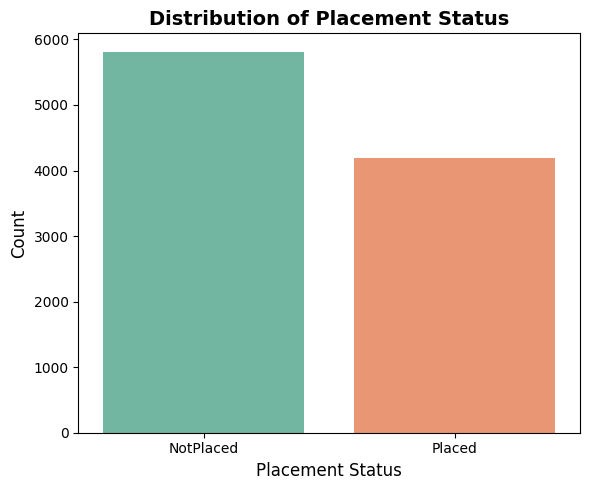

In [9]:
plt.figure(figsize=(6, 5))
sns.countplot(x='PlacementStatus', data=df, palette='Set2')
plt.title('Distribution of Placement Status', fontsize=14, fontweight='bold')
plt.xlabel('Placement Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

Soft Skills vs Technical Skills (Skills Rating vs Communication)

C:\Users\HP\AppData\Local\Temp\ipykernel_14980\3683918425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[0], x='PlacementStatus', y='Skills', data=df, palette='Set2', split=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_14980\3683918425.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[1], x='PlacementStatus', y='Communication Skill Rating', data=df, palette='Set2', split=True)


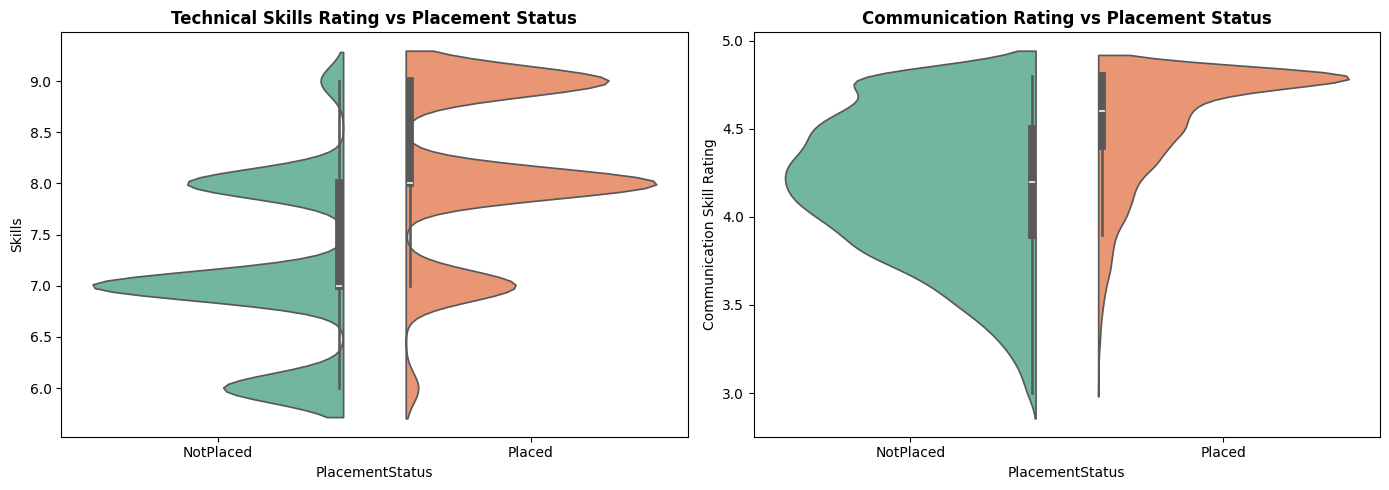

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skills Rating vs Placement Status
sns.violinplot(ax=axes[0], x='PlacementStatus', y='Skills', data=df, palette='Set2', split=True)
axes[0].set_title('Technical Skills Rating vs Placement Status', fontsize=12, fontweight='bold')

# Communication Skill Rating vs Placement Status
sns.violinplot(ax=axes[1], x='PlacementStatus', y='Communication Skill Rating', data=df, palette='Set2', split=True)
axes[1].set_title('Communication Rating vs Placement Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

 Encoding Categorical Columns
Convert Yes/No strings into 1/0 numbers

In [11]:
df['Internship'] = df['Internship'].map({'Yes': 1, 'No': 0})
df['Hackathon'] = df['Hackathon'].map({'Yes': 1, 'No': 0})

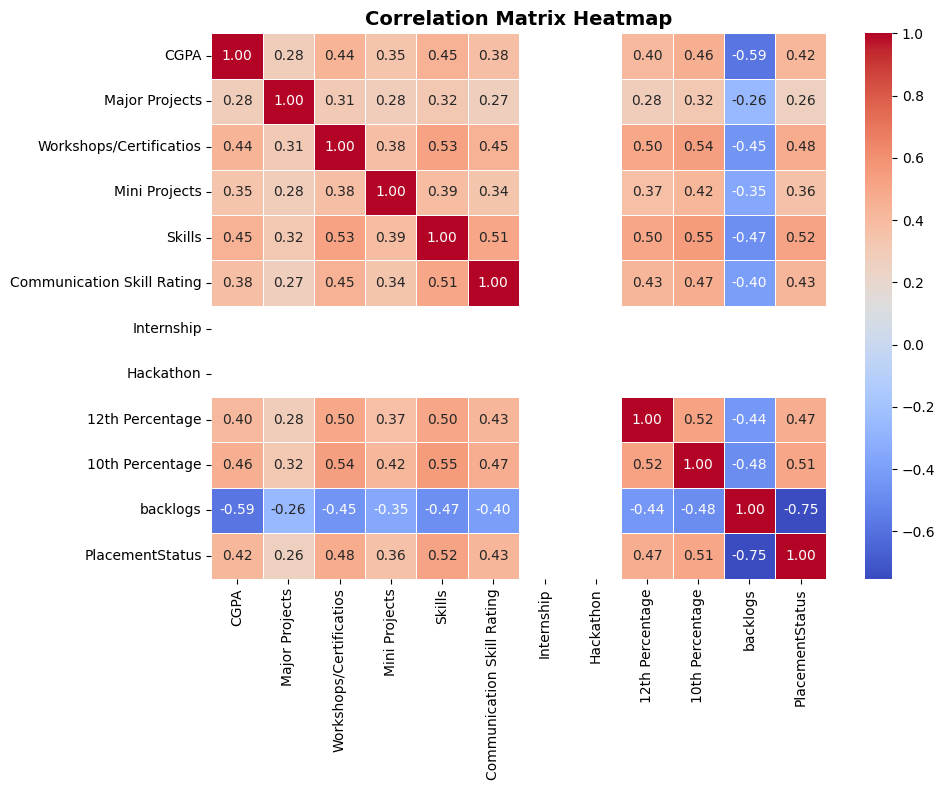

In [12]:
eda_df = df.copy()
eda_df['Internship'] = eda_df['Internship'].map({'Yes': 1, 'No': 0})
eda_df['Hackathon'] = eda_df['Hackathon'].map({'Yes': 1, 'No': 0})
eda_df['PlacementStatus'] = eda_df['PlacementStatus'].map({'Placed': 1, 'NotPlaced': 0})

plt.figure(figsize=(10, 8))
corr_matrix = eda_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Target Encoding: Convert status strings into 1 (Placed) and 0 (NotPlaced)

In [13]:

df['PlacementStatus'] = df['PlacementStatus'].map({'Placed': 1, 'NotPlaced': 0})

Separating Features and Target Label

In [14]:
X = df.drop('PlacementStatus', axis=1)
y = df['PlacementStatus']

Save the feature sequence explicitly to maintain inference alignment

In [15]:
feature_names = X.columns.tolist()
print("Features used for model training:\n", feature_names)

Features used for model training:
 ['CGPA', 'Major Projects', 'Workshops/Certificatios', 'Mini Projects', 'Skills', 'Communication Skill Rating', 'Internship', 'Hackathon', '12th Percentage', '10th Percentage', 'backlogs']


Train-Test Split (80% Training, 20% Testing)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Feature Scaling 

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 Model Building & Training

Using a robust Random Forest setup with defined estimators to optimize speed and variance

In [18]:
model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Model Evaluation Metrics

In [19]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Training Complete!")
print(f"Overall Test Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed']))


Model Training Complete!
Overall Test Accuracy: 94.25%

Classification Report:
               precision    recall  f1-score   support

  Not Placed       0.95      0.95      0.95      1161
      Placed       0.93      0.94      0.93       839

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000

